# AI 프로그래밍 입문 - Week 4

## [실습 과제 (1/3)]

1. 시각화(Matpoltlib / Seaborn)
  * 타이타닉 데이터 로드 및 탐색
  * 생존율 분석 (막대, 파이)
  * 나이·요금 분포 (히스토그램, 박스플롯)
  * 상관관계 히트맵 생성

In [1]:
# 0. 시각화/전처리 모듈 불러오기 등 환경설정
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 임포트 완료")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")

라이브러리 임포트 완료
NumPy 2.4.3 | Pandas 2.3.0 | Matplotlib 3.10.3 | Seaborn 0.13.2


In [3]:
# 1-1 타이타닉 데이터 로드 및 탐색
titanic = sns.load_dataset('titanic')

print("shape:\n", titanic.shape)

print("\n데이터 타입 및 정보:")
print(titanic.info())

print("\n결측치 총합:\n")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

print("\n 수치형 데이터 기초통계량:\n")
print(titanic.describe().round(2))

shape:
 (891, 15)

데이터 타입 및 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

결측치 총합:

age            177
embarked     

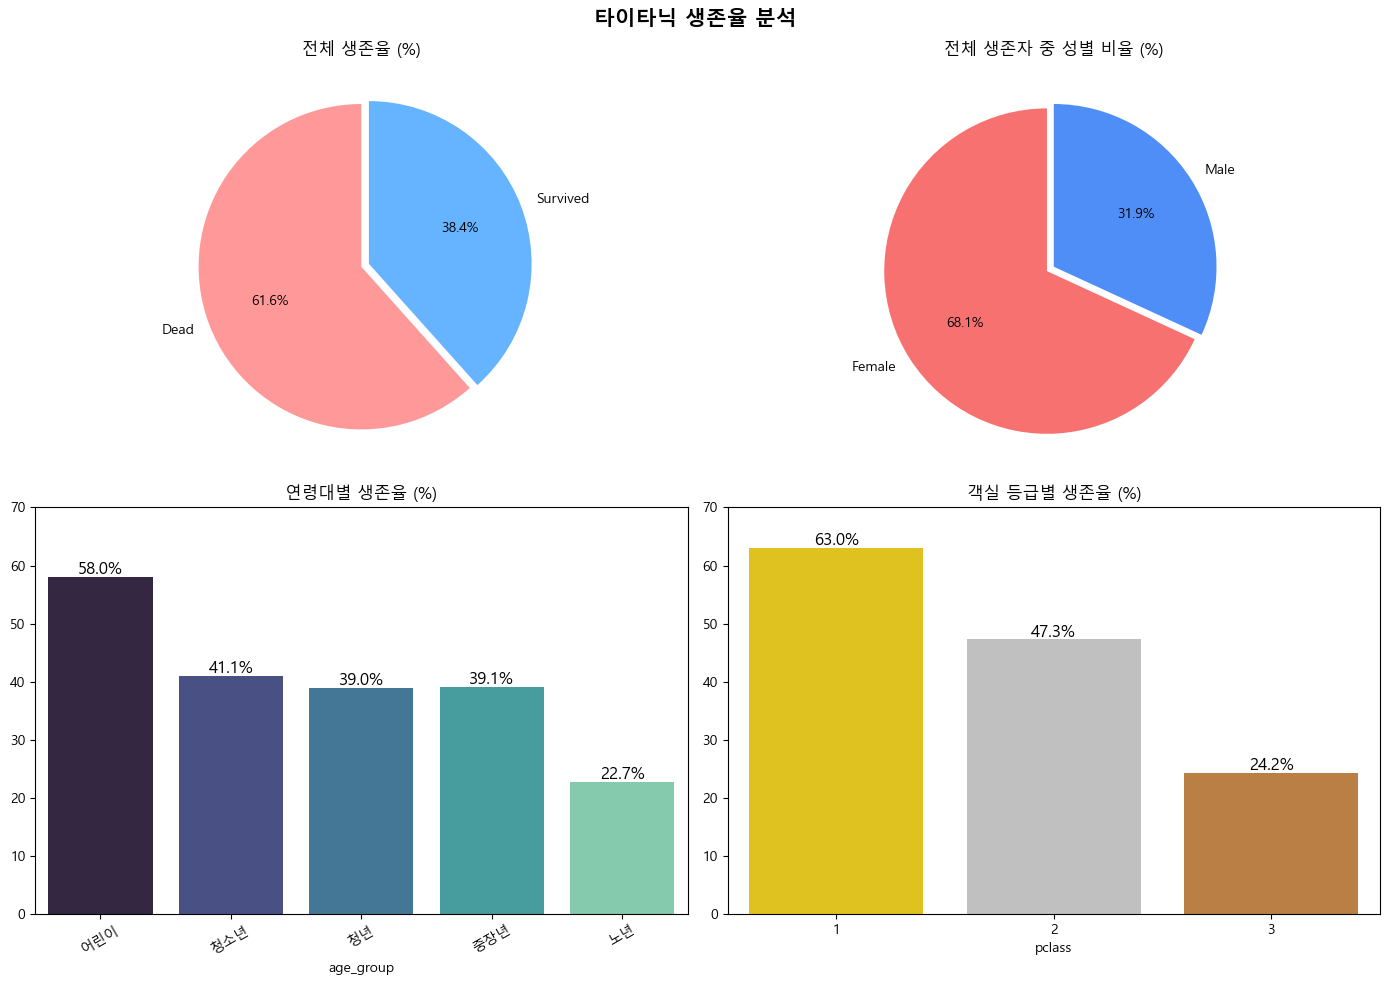

In [4]:

# 1-2 생존률 분석
# 폰트, figure 등 환경 설정
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('타이타닉 생존율 분석', fontsize=15, fontweight='bold')

# 전체 생존율
sur_counts = titanic['survived'].value_counts()
axes[0, 0].pie(sur_counts, 
               labels=['Dead', 'Survived'], 
               autopct='%1.1f%%', 
               startangle=90, 
               colors=['#ff9999', '#66b3ff'], 
               explode=[0, 0.05])
axes[0, 0].set_title('전체 생존율 (%)')

# 전체 생존자 중 성별 비율
survivors_gender = titanic[titanic['survived'] == 1]['sex'].value_counts()
axes[0, 1].pie(survivors_gender, 
               labels=['Female', 'Male'], 
               autopct='%1.1f%%',
               startangle=90, 
               colors=['#f87171', '#4f8ef7'], 
               explode=[0.05, 0])             
axes[0, 1].set_title('전체 생존자 중 성별 비율 (%)')

# 연령대별 생존율
titanic['age_group'] = pd.cut(titanic['age'],
    bins=[0, 12, 19, 40, 60, 100],
    labels=['어린이', '청소년', '청년', '중장년', '노년'])
sur_age = titanic.groupby('age_group', observed=False)['survived'].mean() * 100
sns.barplot(x=sur_age.index, y=sur_age.values, hue=sur_age.index, palette='mako', ax=axes[1, 0])
axes[1, 0].set_title('연령대별 생존율 (%)')
axes[1, 0].tick_params(axis='x', rotation=30)
for i, v in enumerate(sur_age.values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)
axes[1, 0].set_ylim(0, 70)


# 객실 등급별 생존율
sur_cls = titanic.groupby('pclass')['survived'].mean() * 100
sns.barplot(x=sur_cls.index, y=sur_cls.values, hue=sur_cls.index,
            palette=['gold', 'silver', '#cd7f32'], ax=axes[1, 1], legend=False)
axes[1, 1].set_title('객실 등급별 생존율 (%)')
for i, v in enumerate(sur_cls.values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)
axes[1, 1].set_ylim(0, 70)

plt.tight_layout()
plt.show()


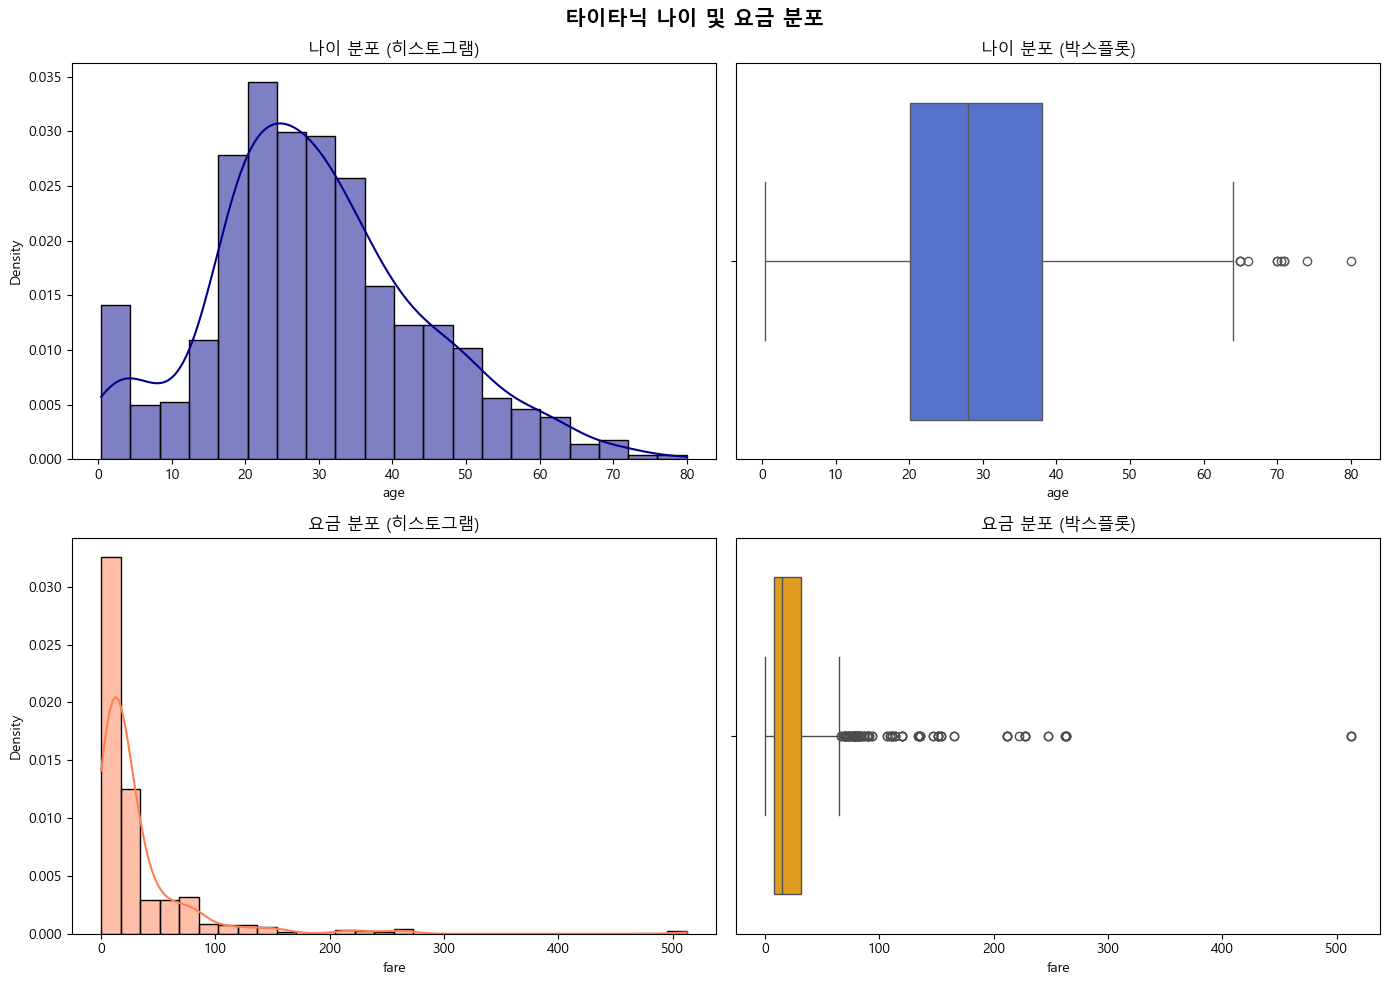

In [5]:
# 1-3 나이·요금 분포 (히스토그램, 박스플롯)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('타이타닉 나이 및 요금 분포', fontsize=15, fontweight='bold')

# 나이 히스토그램
sns.histplot(titanic['age'].dropna(), stat='density', kde=True, ax=axes[0, 0], color='darkblue')
axes[0, 0].set_title('나이 분포 (히스토그램)')

# 나이 박스플롯 (y를 x로 변경)
sns.boxplot(x=titanic['age'], ax=axes[0, 1], color='royalblue')
axes[0, 1].set_title('나이 분포 (박스플롯)')

# 요금 히스토그램
sns.histplot(titanic['fare'], stat='density', kde=True, ax=axes[1, 0], color='coral', bins=30)
axes[1, 0].set_title('요금 분포 (히스토그램)')

# 요금 박스플롯 (y를 x로 변경)
sns.boxplot(x=titanic['fare'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title('요금 분포 (박스플롯)')

plt.tight_layout()
plt.show()


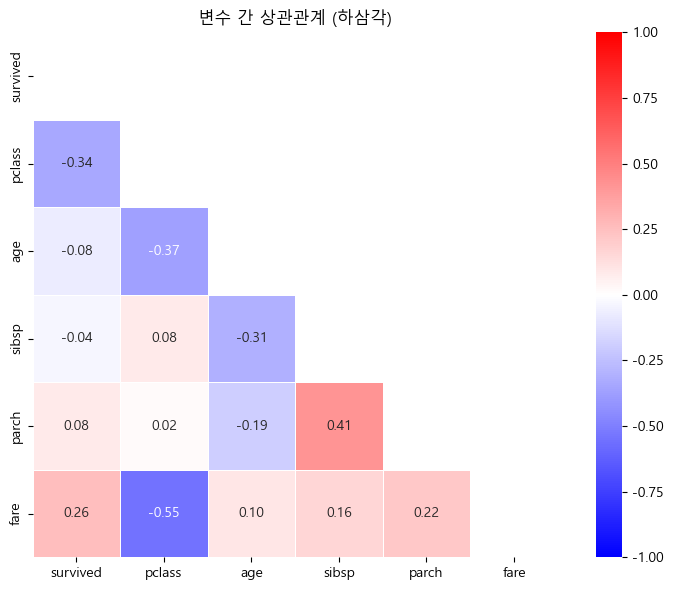

In [6]:
# 1-4 상관관계 히트맵 생성
# 수치 데이터 집합 및 상관계수 계산
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = titanic[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# 그래프 결과물 설정
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='bwr',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('변수 간 상관관계 (하삼각)')
plt.tight_layout()
plt.show()

## [실습 과제 (2/3)]

2. 데이터 전처리
  * Min-Max / Z-score 스케일링 비교 시각화
  * 타이타닉 성별·등급 Label Encoding
  * One-Hot Encoding & 더미 함정 확인
  * 전처리 파이프라인 구성

 t-fare 원본  Min-Max 정규화  Z-score 표준화
      7.25         0.01        -0.50
     71.28         0.14         0.79
      7.92         0.02        -0.49
     53.10         0.10         0.42
      8.05         0.02        -0.49

Min-Max 범위: [0.00, 1.00]

Z-score  평균: 0.00, 표준편차: 1.00



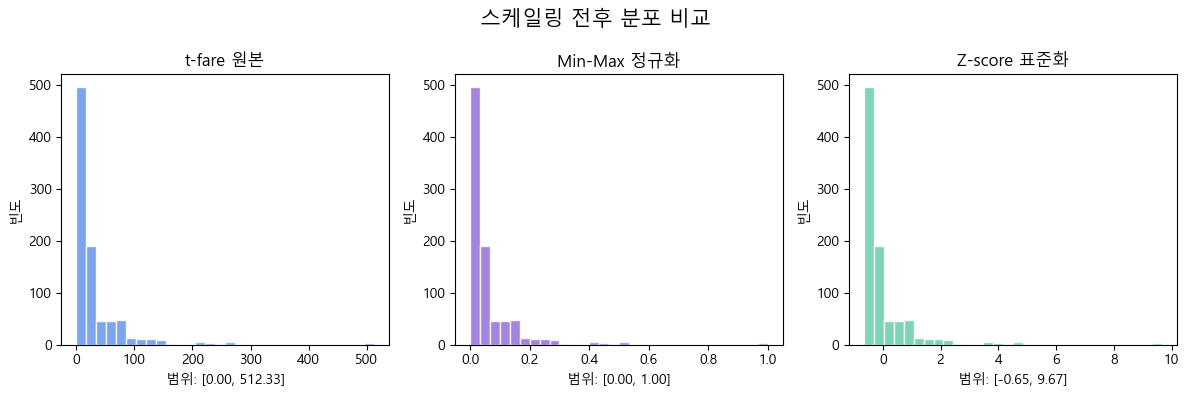

In [7]:
# 2-1 Min-Max / Z-score 스케일링 비교 및 시각화
# 타이타닉 요금 데이터 불러오기 
t_fare = titanic[['fare']]

# Min-Max / Z-score 스케일링(sklearn으로 구현)
t_fare_mm = MinMaxScaler().fit_transform(t_fare)
t_fare_std = StandardScaler().fit_transform(t_fare)

# 원본, Min_Max, Z-score 데이터 비교
t_fare_compare = pd.DataFrame({
    't-fare 원본': t_fare['fare'].round(2),
    'Min-Max 정규화': t_fare_mm.flatten().round(2),
    'Z-score 표준화': t_fare_std.flatten().round(2),
})
print(t_fare_compare.head().to_string(index=False))
print(f"\nMin-Max 범위: [{t_fare_mm.min():.2f}, {t_fare_mm.max():.2f}]")
print(f"\nZ-score  평균: {t_fare_std.mean():.2f}, 표준편차: {t_fare_std.std():.2f}\n")

# 시각화 비교
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('스케일링 전후 분포 비교', fontsize=15)

for ax, d, title, color in zip(
    axes,
    [t_fare['fare'], t_fare_mm.flatten(), t_fare_std.flatten()],
    ['t-fare 원본', 'Min-Max 정규화', 'Z-score 표준화'],
    ['cornflowerblue', 'mediumpurple', 'mediumaquamarine']
) :
    ax.hist(d, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(f'범위: [{d.min():.2f}, {d.max():.2f}]')
    ax.set_ylabel('빈도')

plt.tight_layout()
plt.show()


In [8]:
# 타이타닉 성별 및 등급, 탑승항구 데이터 불러오기(결측치 제거 및 복사)
titanic_enc = titanic[['sex', 'pclass', 'embarked']].dropna().copy()

# 2-2 타이타닉 성별 및 등급 Label Encoding
# 성별 Label Encoding
le = LabelEncoder()
t_gender_encd = le.fit_transform(titanic_enc['sex'])

# 성별 인코딩 결과 확인
print("=== Gender Label Encoding ===")
print(f"클래스: {le.classes_}")
print(f"원본:   {titanic_enc['sex'].values[:10]}")
print(f"인코딩: {t_gender_encd[:10]}")

# 등급 Label Encoding
t_class_encd = le.fit_transform(titanic_enc['pclass'])

# 등급 인코딩 결과 확인
print("\n=== Class Label Encoding ===")
print(f"클래스: {le.classes_}")
print(f"원본:   {titanic_enc['pclass'].values[:10]}")
print(f"인코딩: {t_class_encd[:10]}")

# 여러 컬럼 Label Encoding 적용하기
t_gen_cla_encd = titanic_enc[['sex', 'pclass']].apply(le.fit_transform)

# 여러 컬럼 인코딩 결과 확인
print("\n=== Gender - Class Label Encoding ===")
print(f"원본: \n {titanic_enc[['sex', 'pclass']].values[:10]}")
print(f"인코딩:\n {t_gen_cla_encd[:10]}")


# 2-3 성별 및 탑승항구 sklearn One-Hot Encoding & 더미 함정 방지(drop='first')
t_ohe = OneHotEncoder(drop='first', sparse_output=False)
result = t_ohe.fit_transform(titanic_enc[['sex', 'embarked']])

print("\n=== sklearn OneHotEncoder 결과 ===")
print("특징 이름:", t_ohe.get_feature_names_out(['sex', 'embarked']))
print("\n", result)

=== Gender Label Encoding ===
클래스: ['female' 'male']
원본:   ['male' 'female' 'female' 'female' 'male' 'male' 'male' 'male' 'female'
 'female']
인코딩: [1 0 0 0 1 1 1 1 0 0]

=== Class Label Encoding ===
클래스: [1 2 3]
원본:   [3 1 3 1 3 3 1 3 3 2]
인코딩: [2 0 2 0 2 2 0 2 2 1]

=== Gender - Class Label Encoding ===
원본: 
 [['male' 3]
 ['female' 1]
 ['female' 3]
 ['female' 1]
 ['male' 3]
 ['male' 3]
 ['male' 1]
 ['male' 3]
 ['female' 3]
 ['female' 2]]
인코딩:
    sex  pclass
0    1       2
1    0       0
2    0       2
3    0       0
4    1       2
5    1       2
6    1       0
7    1       2
8    0       2
9    0       1

=== sklearn OneHotEncoder 결과 ===
특징 이름: ['sex_male' 'embarked_Q' 'embarked_S']

 [[1. 0. 1.]
 [0. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 1. 0.]]


=======데이터 원본 및 전처리 데이터 비교========

데이터 원본:
     age     fare  pclass  survived     sex embarked
0  22.0   7.2500       3         0    male        S
1  38.0  71.2833       1         1  female        C
2  26.0   7.9250       3         1  female        S
3  35.0  53.1000       1         1  female        S
4  35.0   8.0500       3         0    male        S

전처리 데이터:
         age      fare  pclass  survived  sex_male  embarked_Q  embarked_S
0 -0.527669 -0.516380       0         0         1           0           1
1  0.577094  0.694046       2         1         0           0           0
2 -0.251478 -0.503620       0         1         0           0           1
3  0.369951  0.350326       2         1         0           0           1
4  0.369951 -0.501257       0         0         1           0           1


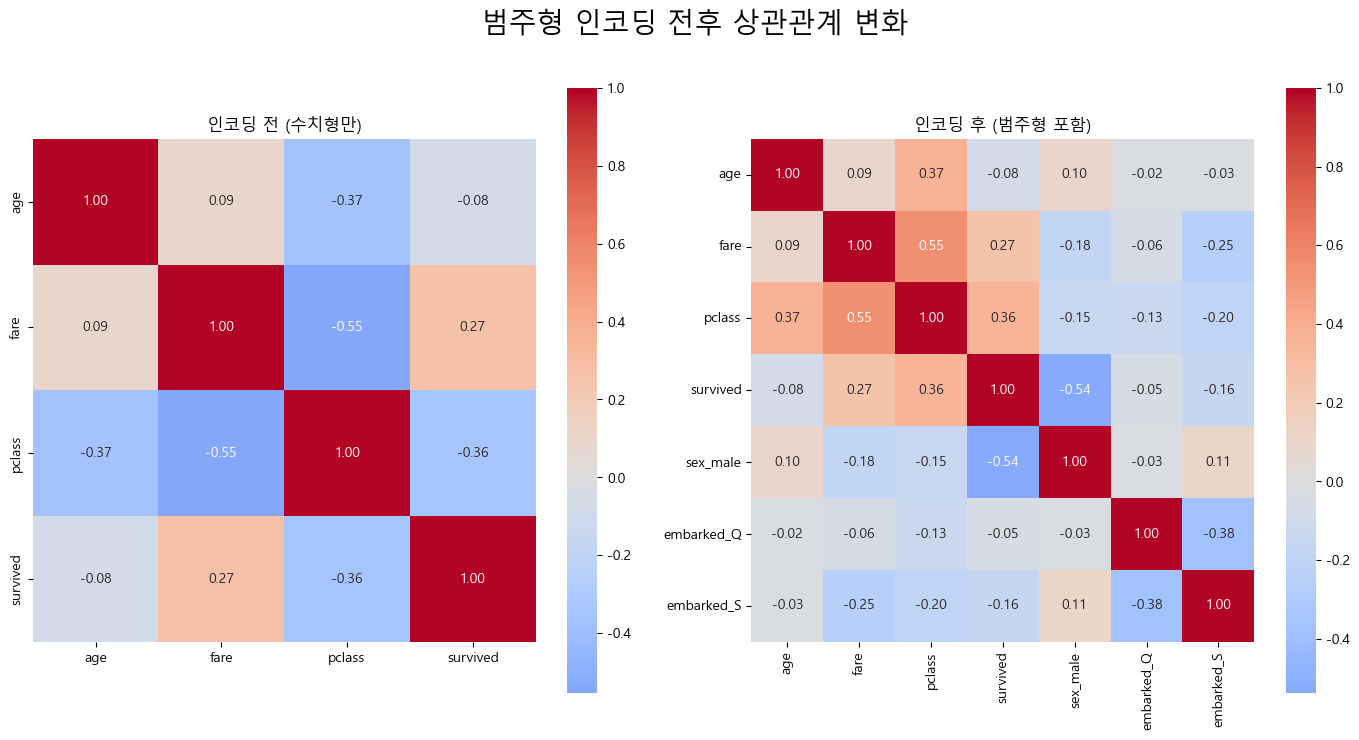

In [9]:
# 2-4 전처리 파이프라인 구성
# 결측치 제거 밑 데이터 복사
titanic_pipeline_raw = titanic[['age', 'fare', 'pclass', 'survived', 'sex', 'embarked']].dropna().copy()
titanic_pipeline = titanic[['age', 'fare', 'pclass', 'survived', 'sex', 'embarked']].dropna().copy()

# 나이와 요금의 스케일 표준화
std = StandardScaler()
titanic_pipeline[['age', 'fare']] = std.fit_transform(titanic_pipeline[['age', 'fare']])

# 등급 Label Encoding - 1등석(2), 2등석(1), 3등석(0) 역순 매핑
titanic_pipeline['pclass'] = titanic_pipeline['pclass'].map({1: 2, 2: 1, 3: 0})

# 성별 및 탑승항구 One-Hot Encoding(drop_first=True 로 더미 함정 방지)
titanic_pipeline = pd.get_dummies(titanic_pipeline, columns=['sex', 'embarked'], drop_first=True, dtype=int)

# 최종 파이프라인 전처리 결과 확인
print('=======데이터 원본 및 전처리 데이터 비교========')
print('\n데이터 원본:\n', titanic_pipeline_raw.head())
print('\n전처리 데이터:\n', titanic_pipeline.head())



### 전처리 및 인코딩 전후 상관관계 변화 확인 ###
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 인코딩 전 (수치형만)
corr_before = titanic_pipeline_raw[['age', 'fare', 'pclass', 'survived']].corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0])
axes[0].set_title('인코딩 전 (수치형만)')

# 인코딩 후 (범주형 포함)
corr_after = titanic_pipeline.corr()
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1])
axes[1].set_title('인코딩 후 (범주형 포함)')

plt.suptitle('범주형 인코딩 전후 상관관계 변화', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

## [실습 과제 (3/3)]

3. Text Embedding
  * Word2vec 학습 및 유사 단어 검색
  * Sentence-BERT 문장 유사도 계산
  * t-SNE로 임베딩 벡터 시각화

In [44]:
# 3-1 word2vec 학습 및 유사단어 검색
# word2vec 모델 임포트
from gensim.models import Word2Vec

# 1단계 문장으로 된 데이터(100문장) 준비 
corpus = [
    # --- [ 1. 동물 / 반려동물 관련 (20문장) ] ---
    "강아지는 귀여운 동물이다", "고양이도 귀여운 반려동물이다", "강아지와 고양이는 인기 있는 반려동물이다", 
    "사자와 호랑이는 맹수이다", "나는 집에서 강아지를 반려동물로 키운다", "고양이는 산책을 싫어하는 동물이다", 
    "작은 강아지는 매우 귀엽다", "호랑이는 밀림의 왕인 사나운 맹수이다", "동물원에는 사자와 호랑이가 산다", 
    "사자는 무리를 지어 사는 거대한 동물이다", "강아지는 사람을 아주 잘 따르는 귀여운 반려동물이다", 
    "고양이는 쥐를 잡는 귀여운 동물이다", "우람한 맹수 중에는 호랑이가 가장 멋지다", "인기 있는 반려동물로 강아지와 고양이를 많이 기른다", 
    "야생 동물인 사자는 고기를 찢어 먹는다", "동물병원에 아픈 고양이와 강아지가 기다리고 있다", "고양이는 털이 매우 부드러운 귀여운 반려동물이다", 
    "주인을 만난 강아지가 반갑게 꼬리를 흔든다", "지구상의 동물에는 포유류인 사자와 호랑이가 있다", "귀여운 강아지가 낯선 사람을 보고 짖고 있다",
    # --- [ 2. AI / 프로그래밍 관련 (20문장) ] ---
    "파이썬은 AI 프로그래밍 핵심 언어이다", "딥러닝과 머신러닝은 최고 수준의 AI 기술이다", "신경망은 딥러닝의 복잡한 핵심 구조이다", 
    "자연어처리는 텍스트를 정밀하게 분석하는 AI 기술이다", "머신러닝 모델은 엄청난 데이터를 꼼꼼히 학습한다", "데이터 분석에는 파이썬이 아주 많이 쓰인다",
    "딥러닝은 사람의 뇌 같은 인공 신경망을 철저히 활용한다", "자연어처리 기술로 우리가 쓰는 챗봇을 멋지게 만든다", "개발자들은 파이썬 코드로 훌륭하게 프로그래밍을 한다",
    "AI는 인간의 훌륭한 지능을 완벽히 모방하는 기술이다", "똑똑한 머신러닝 알고리즘에 방대한 데이터를 매일 입력한다", "수많은 프로그래밍 언어 중에서 파이썬이 제일 인기 있다",
    "빅데이터는 훌륭한 AI와 머신러닝의 필수적인 재료이다", "복잡한 텍스트 분석에 자연어처리가 반드시 필수적이다", "훌륭한 딥러닝 알고리즘이 데이터를 보며 스스로 학습한다",
    "멋진 자율주행 자동차는 뛰어난 AI 기술의 확실한 결과물이다", "대중적인 파이썬 라이브러리로 어려운 딥러닝을 깔끔히 구현한다", "신경망에서 오차를 획기적으로 줄이는 것이 머신러닝이다",
    "수많은 프로그래머들은 편리한 파이썬으로 똑똑한 AI를 완벽히 개발한다", "자연어처리는 컴퓨터가 사람의 언어를 똑똑하게 이해하게 완벽히 돕는다",
    # --- [ 3. 도시 / 지역 / 지리 관련 (20문장) ] ---
    "서울은 대한민국의 오래된 수도이다", "부산은 한국의 뛰어난 항구 도시이다", "서울과 부산은 한국의 거대하고 대표적인 도시이다", 
    "대한민국 커다란 서울에는 맑은 한강이 유유히 흐른다", "수려한 도시 부산에는 유명한 해운대 해수욕장이 확실히 있다", "거대한 서울은 세계적으로 아주 유명하고 큰 수도이다",
    "인천은 번화한 서울 근처의 매우 큰 도시이다", "대한민국의 복잡한 수도인 인구 많은 서울은 참 화려하다", "많은 한국 사람들은 아름다운 부산 여행을 정말로 좋아한다",
    "반짝이는 서울의 늦은 야경은 모든 도시 중에서 가장 엄청나게 아름답다", "유명한 항구 도시 부산에는 진짜 맛있는 해산물이 너무도 많다", "거대한 수도 서울로 셀 수 없는 많은 사람들이 바쁘게 일하러 온다",
    "대한민국 한국의 현대적인 도시들은 모든 대중 교통이 완벽히 편리하다", "대전은 커다란 한국의 따뜻한 중부 지역에 위치한 도시이다", "거대한 서울은 아름다운 대한민국의 튼튼한 경제와 화려한 문화 중심지이다",
    "수많은 관광객들은 즐겁게 서울과 매력적인 부산을 매년 자주 방문한다", "제주도는 커다란 한국에서 외국인 관광객이 가장 많은 아름다운 섬이다", "거대한 수도권은 꽉 찬 서울 주변 모든 활기찬 도시를 넓게 포함한다",
    "멋진 대한민국의 찬란한 수도는 훌륭하고 역사적인 거대한 도시이다", "다양하게 많은 항구 도시 중에서 멋진 부산이 제일 크다",
    # --- [ 4. 스포츠 / 구기 종목 관련 (20문장) ] ---
    "야구는 한국에서 인기 있는 훌륭한 스포츠이다", "축구와 야구는 짜릿한 팀 스포츠이다", "화려한 월드컵은 아주 세계적인 거대 축구 스포츠 대표 대회이다", 
    "넓은 야구장에는 수많은 열성적인 스포츠 팬들이 가득 모여 엄청나게 인기있다", "유명한 축구 선수가 힘차게 공을 차서 멋지게 골을 완벽히 넣었다", "신나는 팀 스포츠 야구는 훌륭한 여러 명이 다 함께 즐겁게 한다",
    "대부분의 한국 사람들은 스릴 있는 야구와 박진감 넘치는 축구를 주말에 즐긴다", "거대한 올림픽에서 셀 수 없이 다양한 재미있는 스포츠 경기가 화려하게 열린다", "가장 인기 스포츠 중에는 신나는 축구가 단연코 으뜸이다",
    "신나는 야구는 단단한 방망이로 하얀 공을 멀리 치는 팀 스포츠이다", "역동적인 축구는 땀 흘리는 열한 명의 선수가 열심히 뛰는 팀 스포츠이다", "추운 겨울에는 실내 농구와 신나는 배구가 최고로 인기 있는 따뜻한 스포츠이다",
    "훌륭한 스포츠 선수들은 엄청나게 튼튼하고 건강한 강인한 체력을 당연히 가진다", "두 팀을 치열하게 나눠서 짜릿한 승부를 정정당당히 겨루는 것이 스포츠이다", "열띤 축구 경기에서 관중을 놀래키는 흥미진진한 명장면이 많이 나왔다",
    "수많은 팬들은 자신이 열렬히 응원하는 멋진 야구 팀을 최고로 좋아한다", "거칠고 신나는 축구는 서로 돕는 팀워크가 무엇보다 중요한 팀 스포츠이다", "가장 인기 스포츠인 신나는 야구는 주말마다 환호하는 관중이 정말로 많다",
    "건강한 스포츠는 평범한 사람들에게 벅찬 감동과 짜릿한 재미를 확실하게 준다", "멋진 야구 선수가 시원하게 홈런을 뻥 치면 그 팀이 짜릿하게 이긴다",
    # --- [ 5. 과일 / 채소 / 음식 관련 (20문장) ] ---
    "사과와 바나나는 달콤한 과일이다", "당근과 오이는 신선한 채소이다", "가게에서 동그란 과일인 빨간 사과와 노란 바나나를 샀다", 
    "튼튼한 건강을 위해 아삭한 채소인 주황빛 당근과 초록색 오이를 매일 거르지 않고 먹는다", "맛있는 사과는 엄청나게 달콤하고 향이 참 좋은 붉은 과일이다", "배고픈 원숭이가 껍질이 노란 과일 바나나를 허겁지겁 먹는다",
    "아삭한 당근은 눈에 좋은 비타민이 아주 다량으로 많은 훌륭한 건강한 채소이다", "더운 여름에 갈증을 달래는 시원한 채소 오이를 썰어서 요리해 맛있게 먹는다", "새콤하고 신선한 사과와 부드러운 바나나는 내가 제일 좋아하는 맛있는 과일이다",
    "신선한 샐러드에는 아삭아삭한 당근과 푸른 오이 같은 싱싱한 채소가 한가득 들어간다", "상쾌한 아침에 깨끗한 과일 사과를 껍질째 먹으면 우리 몸 건강에 무척 좋다", "길쭉한 오이는 몸에 좋은 수분이 최고로 꽉 찬 시원한 채소이다",
    "노르스름한 바나나는 하얀 껍질을 스윽 벗겨 크게 한입에 먹는 달달한 열대 과일이다", "기름진 고기와 함께 깨끗한 채소인 아삭한 당근을 불에 구워 아주 맛있게 먹었다", "동네 시장에서 막 수확한 싱싱한 녹색 채소 오이와 붉은 당근을 묶음으로 판다",
    "새콤달콤한 과일 중 단단한 사과는 아주 다양하게 많은 상큼한 요리에 주로 쓰인다", "몸에 좋은 당근 채소를 송송 썰어 넣으면 모든 식당의 음식이 훨씬 맛있어진다", "어린 아이들은 씹기 좋고 달콤한 최고 과일 바나나를 매일 아침 좋아한다",
    "맛있는 채소는 제일 신선할 때 푸른 오이와 달착지근한 당근이 가장 아삭하고 시원하다", "달콤한 사과와 부드러운 바나나 등 상큼한 과일을 밥 먹고 후식으로 매번 즐긴다"
]

# 2단계-1 간단 전처리(공백 분리/단어 단위로 쪼개기)
remove_chars = ['은', '는', '를', '이다', '있다', '와', '과', '도', '의', '에', '에는', '에서']
tokenized = []
for sent in corpus:
    for ch in remove_chars:
        sent = sent.replace(ch, ' ')
    tokenized.append(sent.split())

# 3단계 word2vec 학습
w2v = Word2Vec(
    sentences=tokenized, # 문장을 쪼개서 만든 단어장으로 학습
    vector_size=50,      # 단어 하나당 n개의 좌표 배정(비슷한 의미 단어끼리 뭉칠 수 있는 위치)
    window=3,            # 특정 단어의 앞 뒤로 3개의 단어까지 참조해서 문맥 파악
    min_count=1,         # 준비한 데이터 수가 작으므로 1번만 나온 단어도 암기(원래는 너무 적게 등장한 단어는 무시함)
    sg=1,                # Skip-gram : 하나의 단어를 보고 주변 단어를 유추
    seed=42,
    epochs=120

)
print(f"✅ Word2Vec 학습 완료 | 어휘: {len(w2v.wv.key_to_index)}개 단어")

# 4단계 학습된 모델 테스트
print('\n=======유사 단어 검색========')
for word in ['강아지', '파이썬', '서울']:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=3)  # 검색대상 단어와 유사한 단어 3개 뽑기
        print(f"\n'{word}' 유사 단어:")
        for w, s in similar:
            print(f"  {w:10s} {s:.3f}")  # {w:10s} : 문자 찍을 때 10칸 공간 확보, s : 유사도 점수(Similarity Score)=코사인 유사도 -1 ~ 1(1 에 근접할 수록 유사단어, 0에 근접할 수록 두단어 멀리 떨어짐, -1 완전히 정반대 의미)

✅ Word2Vec 학습 완료 | 어휘: 464개 단어

=======유사 단어 검색========

'강아지' 유사 단어:
  반려동물로      0.964
  고양이        0.958
  반려동물       0.956

'파이썬' 유사 단어:
  코드로        0.949
  라이브러리로     0.942
  훌륭하게       0.942

'서울' 유사 단어:
  대한민국       0.941
  거대한        0.923
  훌륭하고       0.918


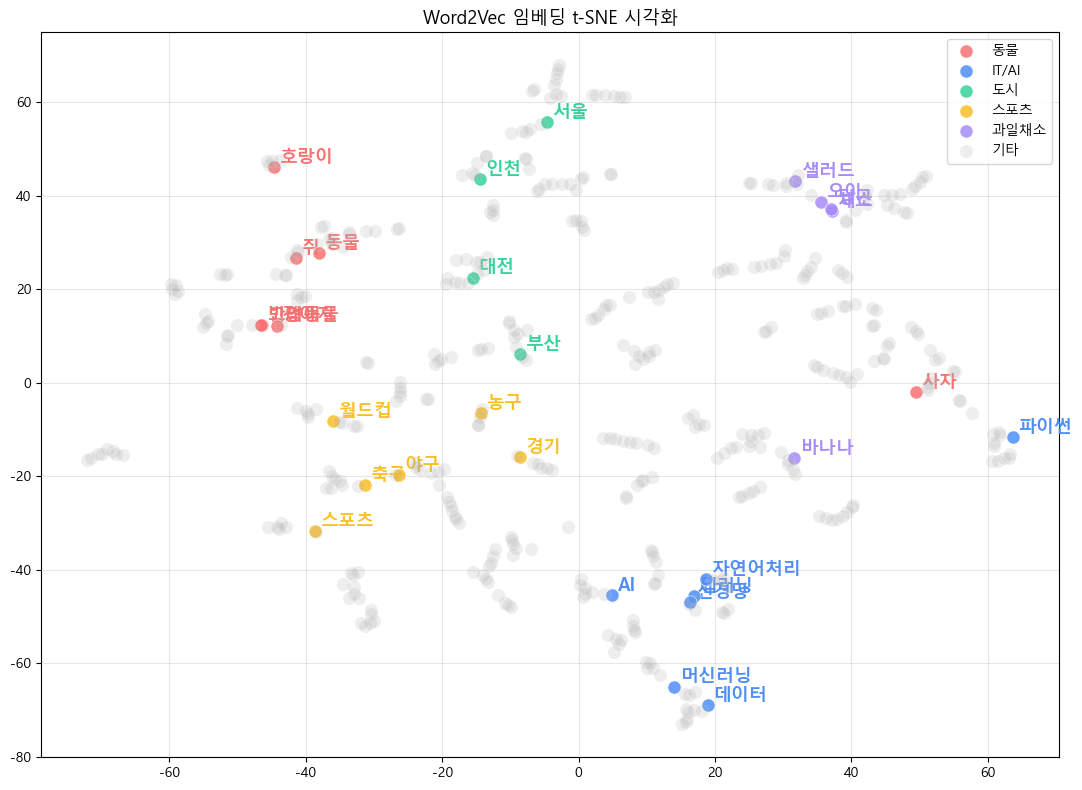

In [58]:
# 3-3 t-SNE로 임베딩 시각화
# 3-3-1 word2vec 임베딩 시각화 
from sklearn.manifold import TSNE

words   = list(w2v.wv.key_to_index.keys())
vectors = np.array([w2v.wv[w] for w in words])

tsne = TSNE(n_components=2, perplexity=5, random_state=42,
            max_iter=1000, learning_rate='auto', init='pca')
reduced = tsne.fit_transform(vectors)

category_map = {
    '동물': ['강아지', '고양이', '사자', '호랑이', '반려동물', '동물', '쥐'],
    'IT/AI': ['파이썬', '딥러닝', '머신러닝', '신경망', '자연어처리', 'AI', '데이터'],
    '도시': ['서울', '부산', '인천', '대전', '제주도', '수도', '도시'],
    '스포츠': ['야구', '축구', '농구', '배구', '스포츠', '월드컵', '경기'],
    '과일채소':  ['사과', '샐러드', '당근', '오이', '과일', '채소', '바나나'],
}
palette = {'동물': '#f87171', 'IT/AI': '#4f8ef7', '도시': '#34d399',
           '스포츠': '#fbbf24', '과일채소': '#a78bfa', '기타': '#aaa'}

word_colors = {}
for w in words:
    word_colors[w] = palette['기타']
    for cat, cws in category_map.items():
        if w in cws:
            word_colors[w] = palette[cat]; break

# 기타 항목은 투명도를 높이고 글자를 적지 않기 / 주요 5개 카테고리는 글자를 진하게
fig, ax = plt.subplots(figsize=(11, 8))
for cat, color in palette.items():
    idx = [i for i, w in enumerate(words) if word_colors[w] == color]
    if idx:
        current_alpha = 0.2 if cat == '기타' else 0.85
        current_size = 40 if cat == '기타' else 90
        ax.scatter(reduced[idx, 0], reduced[idx, 1],
                   c=color, s=90, alpha=current_alpha, label=cat,
                   edgecolors='white', linewidth=0.5, zorder=5)

for i, word in enumerate(words):
    color = word_colors.get(word, palette['기타'])
    if color != palette['기타']:
        ax.annotate(word, xy=(reduced[i, 0], reduced[i, 1]),
            xytext=(4, 3), textcoords='offset points',
            fontsize=13, fontweight='bold', color=color)

ax.set_title('Word2Vec 임베딩 t-SNE 시각화', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 3-2 Sentence-BERT 문장 유사도 계산
# Sentence-BERT 모델, 코사인 유사도 계산 모듈 임포트
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim

    print("모델 로딩 중...")
    sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    print("모델 로드 완료")
    SBERT_AVAILABLE = True
except ImportError:
    print("pip install sentence-transformers 후 재실행하세요.")
    SBERT_AVAILABLE = False


모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


임베딩 완료

임베딩 shape: (15, 384)


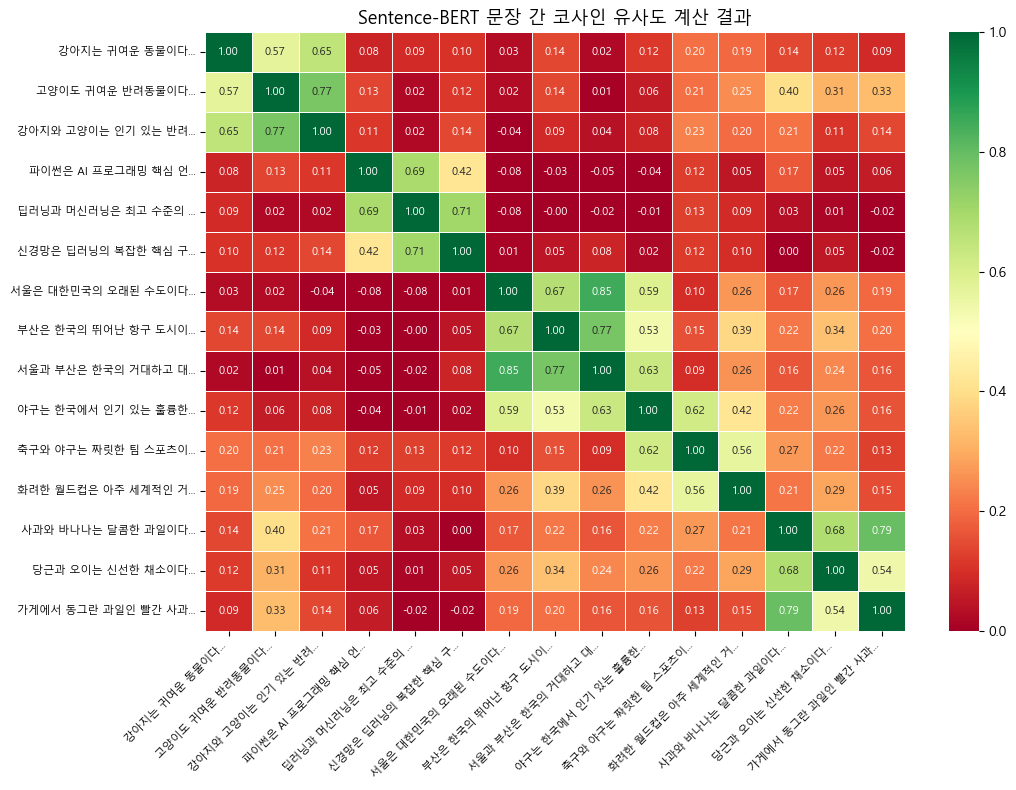

In [64]:
# 3-2 Sentence-BERT 문장 유사도 계산
# Sentence-BERT 임베딩
if SBERT_AVAILABLE:
    sentences = [
        # --- [ 1. 동물 / 반려동물 관련 (3문장) ] ---
        "강아지는 귀여운 동물이다", "고양이도 귀여운 반려동물이다", "강아지와 고양이는 인기 있는 반려동물이다", 
        # --- [ 2. AI / 프로그래밍 관련 (3문장) ] ---
        "파이썬은 AI 프로그래밍 핵심 언어이다", "딥러닝과 머신러닝은 최고 수준의 AI 기술이다", "신경망은 딥러닝의 복잡한 핵심 구조이다",  
        # --- [ 3. 도시 / 지역 / 지리 관련 (3문장) ] ---
        "서울은 대한민국의 오래된 수도이다", "부산은 한국의 뛰어난 항구 도시이다", "서울과 부산은 한국의 거대하고 대표적인 도시이다", 
        # --- [ 4. 스포츠 / 구기 종목 관련 (3문장) ] ---
        "야구는 한국에서 인기 있는 훌륭한 스포츠이다", "축구와 야구는 짜릿한 팀 스포츠이다", "화려한 월드컵은 아주 세계적인 거대 축구 스포츠 대표 대회이다", 
        # --- [ 5. 과일 / 채소 / 음식 관련 (3문장) ] ---
        "사과와 바나나는 달콤한 과일이다", "당근과 오이는 신선한 채소이다", "가게에서 동그란 과일인 빨간 사과와 노란 바나나를 샀다", 
    ]
    labels_cat = ['동물', '동물', '동물', 'IT/AI', 'IT/AI', 'IT/AI', '도시', '도시', '도시', '스포츠', '스포츠',
                 '스포츠','과일채소', '과일채소', '과일채소']


    embeddings = sbert.encode(sentences, show_progress_bar=True)
    print(f"\n임베딩 완료")
    print(f"\n임베딩 shape: {embeddings.shape}")

    # 코사인 유사도 계산
    sim_matrix = cos_sim(embeddings)

    # 히트맵으로 시각화 
    short = [s[:18] + '...' for s in sentences]
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(sim_matrix, xticklabels=short, yticklabels=short,
                annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
    ax.set_title('Sentence-BERT 문장 간 코사인 유사도 계산 결과', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()    

    plt.show()

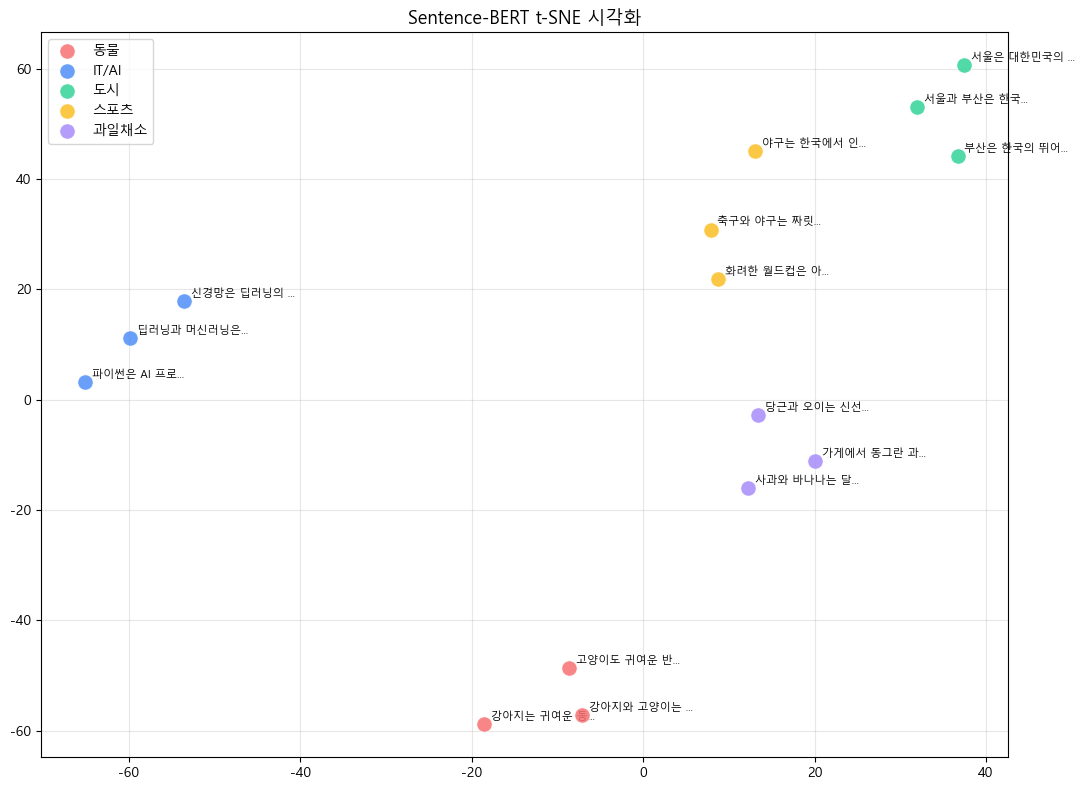

In [68]:
# 3-3 t-SNE로 임베딩 시각화
# 3-3-2 Sentence-BERT 임베딩 시각화 
if SBERT_AVAILABLE:
    tsne_s = TSNE(n_components=2, perplexity=3, random_state=42,
                  max_iter=2000, learning_rate='auto', init='pca')
    red_s = tsne_s.fit_transform(embeddings)

    cat_pal = {'동물': '#f87171', 'IT/AI': '#4f8ef7', '도시': '#34d399',
           '스포츠': '#fbbf24', '과일채소': '#a78bfa'}

    fig, ax = plt.subplots(figsize=(11, 8))
    for cat, color in cat_pal.items():
        idx = [i for i, l in enumerate(labels_cat) if l == cat]
        ax.scatter(red_s[idx, 0], red_s[idx, 1],
                   c=color, s=120, alpha=0.85, label=cat,
                   edgecolors='white', linewidth=0.5, zorder=5)

    for i, sent in enumerate(sentences):
        ax.annotate(sent[:10] + '...',
                    xy=(red_s[i, 0], red_s[i, 1]),
                    xytext=(5, 3), textcoords='offset points', fontsize=8)

    ax.set_title('Sentence-BERT t-SNE 시각화', fontsize=13)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 실습소감
단순히 주어진 코드를 실행하는 것을 넘어 타이타닉 데이터를 이용해서 자료를 직접 분석해보고 각종 인코딩 기법과 시각화 기법을 배울 수 있었습니다. 또한 Word2Vec과 SBERT가 단어의 문맥을 군집화해 내는 과정을 직접 체험해 볼 수 있는 좋은 과제였습니다. 
마지막으로 실습과정에 생긴 오류들을 분석하는데 안티그래비티 프로그램의 도움을 많이 받았는데 학업에 더욱 분발해야겠다는 반성을 하는 한편, 연구를 진행하는데 큰 도움이되는 좋은 프로그램 소개해주신 교수님께 감사드립니다.  